In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionario de dados

- ano: Ano de aplicação da avaliação estadual
- id_municipio: ID município de 7 dígitos
- id_escola: Máscara do códigoo da escola (códigos fictícios)
- id_aluno: Código do aluno
- caderno: Código do caderno atribuído ao aluno na prova de língua portuguesa
- serie: Ano escolar
- rede: Dependência administrativa da escola
- presenca: Indicador de presença na prova de língua portuguesa
- preenchimento_caderno: Indicador de preenchimento da prova de língua portuguesa
- alfabetizado: Indica se o aluno, mediante o resultado da avaliação estadual, é considerado alfabetizado
- proficiencia: Proficiência do aluno em língua portuguesa calculada na escala equalizada com o SAEB
- peso_aluno: Peso do aluno na prova de língua portuguesa
- sigla_uf:estado onde alino esta registrado
- regiao: regiao onde aluno esta registrado
- mun_taxa_alfabetizacao: Percentual dos alunos avaliados no município que foram considerados, mediante o resultado da avaliação estadual, como alfabetizados
- mun_prop_nivel_...0 ao 8: Percentual de alunos avaliados no município que foram alocados no nível de desempenho `n` na avaliação estadual de Lingua Portuguesa (LP)
- mun_nivel_alfabetizacao: Nível de alfabetização
- mun_percentual_participacao: Percentual de participação no município	
- gap_mun_meta_2030: calculada de mun_taxa_alfabetizacao - meta_alfabetizacao_2030
- uf_taxa_alfabetizacao: Percentual dos alunos avaliados no estado que foram considerados, mediante o resultado da avaliação estadual, como alfabetizados
- uf_media_portugues: Média ponderada do estado na avaliação estadual na disciplina Língua Portuguesa equalizada com o SAEB
- gap_mun_vs_uf: calculada de mun_taxa_alfabetizacao - uf_taxa_alfabetizacao
- mun_media_portugues: Média ponderada do município na avaliação estadual na disciplina Língua Portuguesa (LP) equalizada com o SAEB

# 1. Carregando Tabelas

In [2]:
# Carregando tabelas

ANOS = [2023, 2024]
df = pd.concat([
    pd.read_parquet(f"../data/silver/integrado/year={ano}/dados.parquet")
    for ano in ANOS
], ignore_index=True)

In [3]:
print(f'tamanho do nosso dataset (Linhas, Colunas): {df.shape}')

tamanho do nosso dataset (Linhas, Colunas): (3355822, 31)


In [4]:
df.head()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,...,mun_prop_nivel_5,mun_prop_nivel_6,mun_prop_nivel_7,mun_prop_nivel_8,mun_nivel_alfabetizacao,mun_percentual_participacao,gap_mun_meta_2030,uf_taxa_alfabetizacao,uf_media_portugues,gap_mun_vs_uf
0,2023,3300704,60025977,33014516,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,2.0,77.39,-25.42,52.13,737.3032,2.45
1,2023,3121605,60021971,31008498,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,2.0,91.70,-20.46,58.74,750.4243,0.80
2,2023,3157807,60018571,31151092,1,2,Estadual,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.65,756.3436,-9.90
3,2023,4204806,60035456,42032360,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,1.0,79.47,-31.44,62.04,747.7686,-13.48
4,2023,4204806,60035456,42032357,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,1.0,79.47,-31.44,62.04,747.7686,-13.48


In [5]:
df.tail()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,...,mun_prop_nivel_5,mun_prop_nivel_6,mun_prop_nivel_7,mun_prop_nivel_8,mun_nivel_alfabetizacao,mun_percentual_participacao,gap_mun_meta_2030,uf_taxa_alfabetizacao,uf_media_portugues,gap_mun_vs_uf
3355817,2024,4322400,60038978,43098836,9,2,Municipal,1,1,0,...,22.13,14.29,3.64,1.06,1.0,74.64,-32.70,44.23,733.9263,3.07
3355818,2024,2602902,60013156,26035176,9,2,Municipal,1,1,0,...,28.06,14.31,2.67,0.62,2.0,91.65,-29.28,60.76,747.2800,-10.04
3355819,2024,4314902,60038096,43065853,9,2,Estadual,1,1,0,...,13.82,8.22,3.29,1.28,NaN,NaN,NaN,45.63,734.9670,-14.33
3355820,2024,3167202,60019847,31182116,9,2,Municipal,1,1,1,...,31.10,15.78,4.61,1.91,3.0,87.26,-19.65,71.45,757.4100,-11.10
3355821,2024,5300108,60042409,53014042,9,2,Estadual,1,1,0,...,33.05,13.13,3.10,0.71,NaN,NaN,NaN,NaN,NaN,NaN


## 1.1 Analisando nulos

In [8]:
nulos = df.isnull().mean().sort_values(ascending=False) * 100
nulos = nulos[nulos > 0]
print("Percentual de nulos por coluna:")
nulos

Percentual de nulos por coluna:


mun_prop_nivel_6               44.790099
mun_prop_nivel_4               44.790099
mun_prop_nivel_5               44.790099
mun_prop_nivel_3               44.790099
mun_prop_nivel_2               44.790099
mun_prop_nivel_1               44.790099
mun_prop_nivel_8               44.790099
mun_prop_nivel_7               44.790099
mun_prop_nivel_0               44.790099
mun_nivel_alfabetizacao        13.037908
mun_percentual_participacao    13.037908
gap_mun_meta_2030              12.731545
gap_mun_vs_uf                   0.664278
uf_taxa_alfabetizacao           0.658885
uf_media_portugues              0.658885
proficiencia                    0.035312
peso_aluno                      0.035312
mun_taxa_alfabetizacao          0.005394
mun_media_portugues             0.005394
dtype: float64

# 2. Análise Descritiva

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,3355822.0,NaN,NaN,NaN,2023.552104,0.497278,2023.0,2023.0,2024.0,2024.0,2024.0
id_municipio,3355822.0,NaN,NaN,NaN,3215675.198125,1033473.778278,1100015.0,2510501.0,3170107.0,4106902.0,5300108.0
id_escola,3355822.0,NaN,NaN,NaN,60021802.2615,12549.161898,60000001.0,60011249.0,60022103.0,60032799.75,60042811.0
id_aluno,3355822.0,NaN,NaN,NaN,32097807.577066,10333965.966297,11000001.0,25025676.0,31189940.0,41041128.0,53027700.0
caderno,3355822.0,NaN,NaN,NaN,10.708115,6.137732,1.0,5.0,11.0,16.0,43.0
serie,3355822.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
rede,3355822,2,Municipal,2983123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presenca,3355822.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
preenchimento_caderno,3355822.0,NaN,NaN,NaN,0.999647,0.018788,0.0,1.0,1.0,1.0,1.0
alfabetizado,3355822.0,NaN,NaN,NaN,0.591369,0.491581,0.0,0.0,1.0,1.0,1.0


In [5]:
lista_variaveis =  [
'alfabetizado','proficiencia',
'mun_media_portugues','mun_taxa_alfabetizacao',
'mun_prop_nivel_0','mun_prop_nivel_1',
'mun_prop_nivel_2', 'mun_prop_nivel_3', 'mun_prop_nivel_4',
'mun_prop_nivel_5', 'mun_prop_nivel_6',
'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
'mun_percentual_participacao', 'gap_mun_meta_2030',
'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'
]

df_dist = df[lista_variaveis]

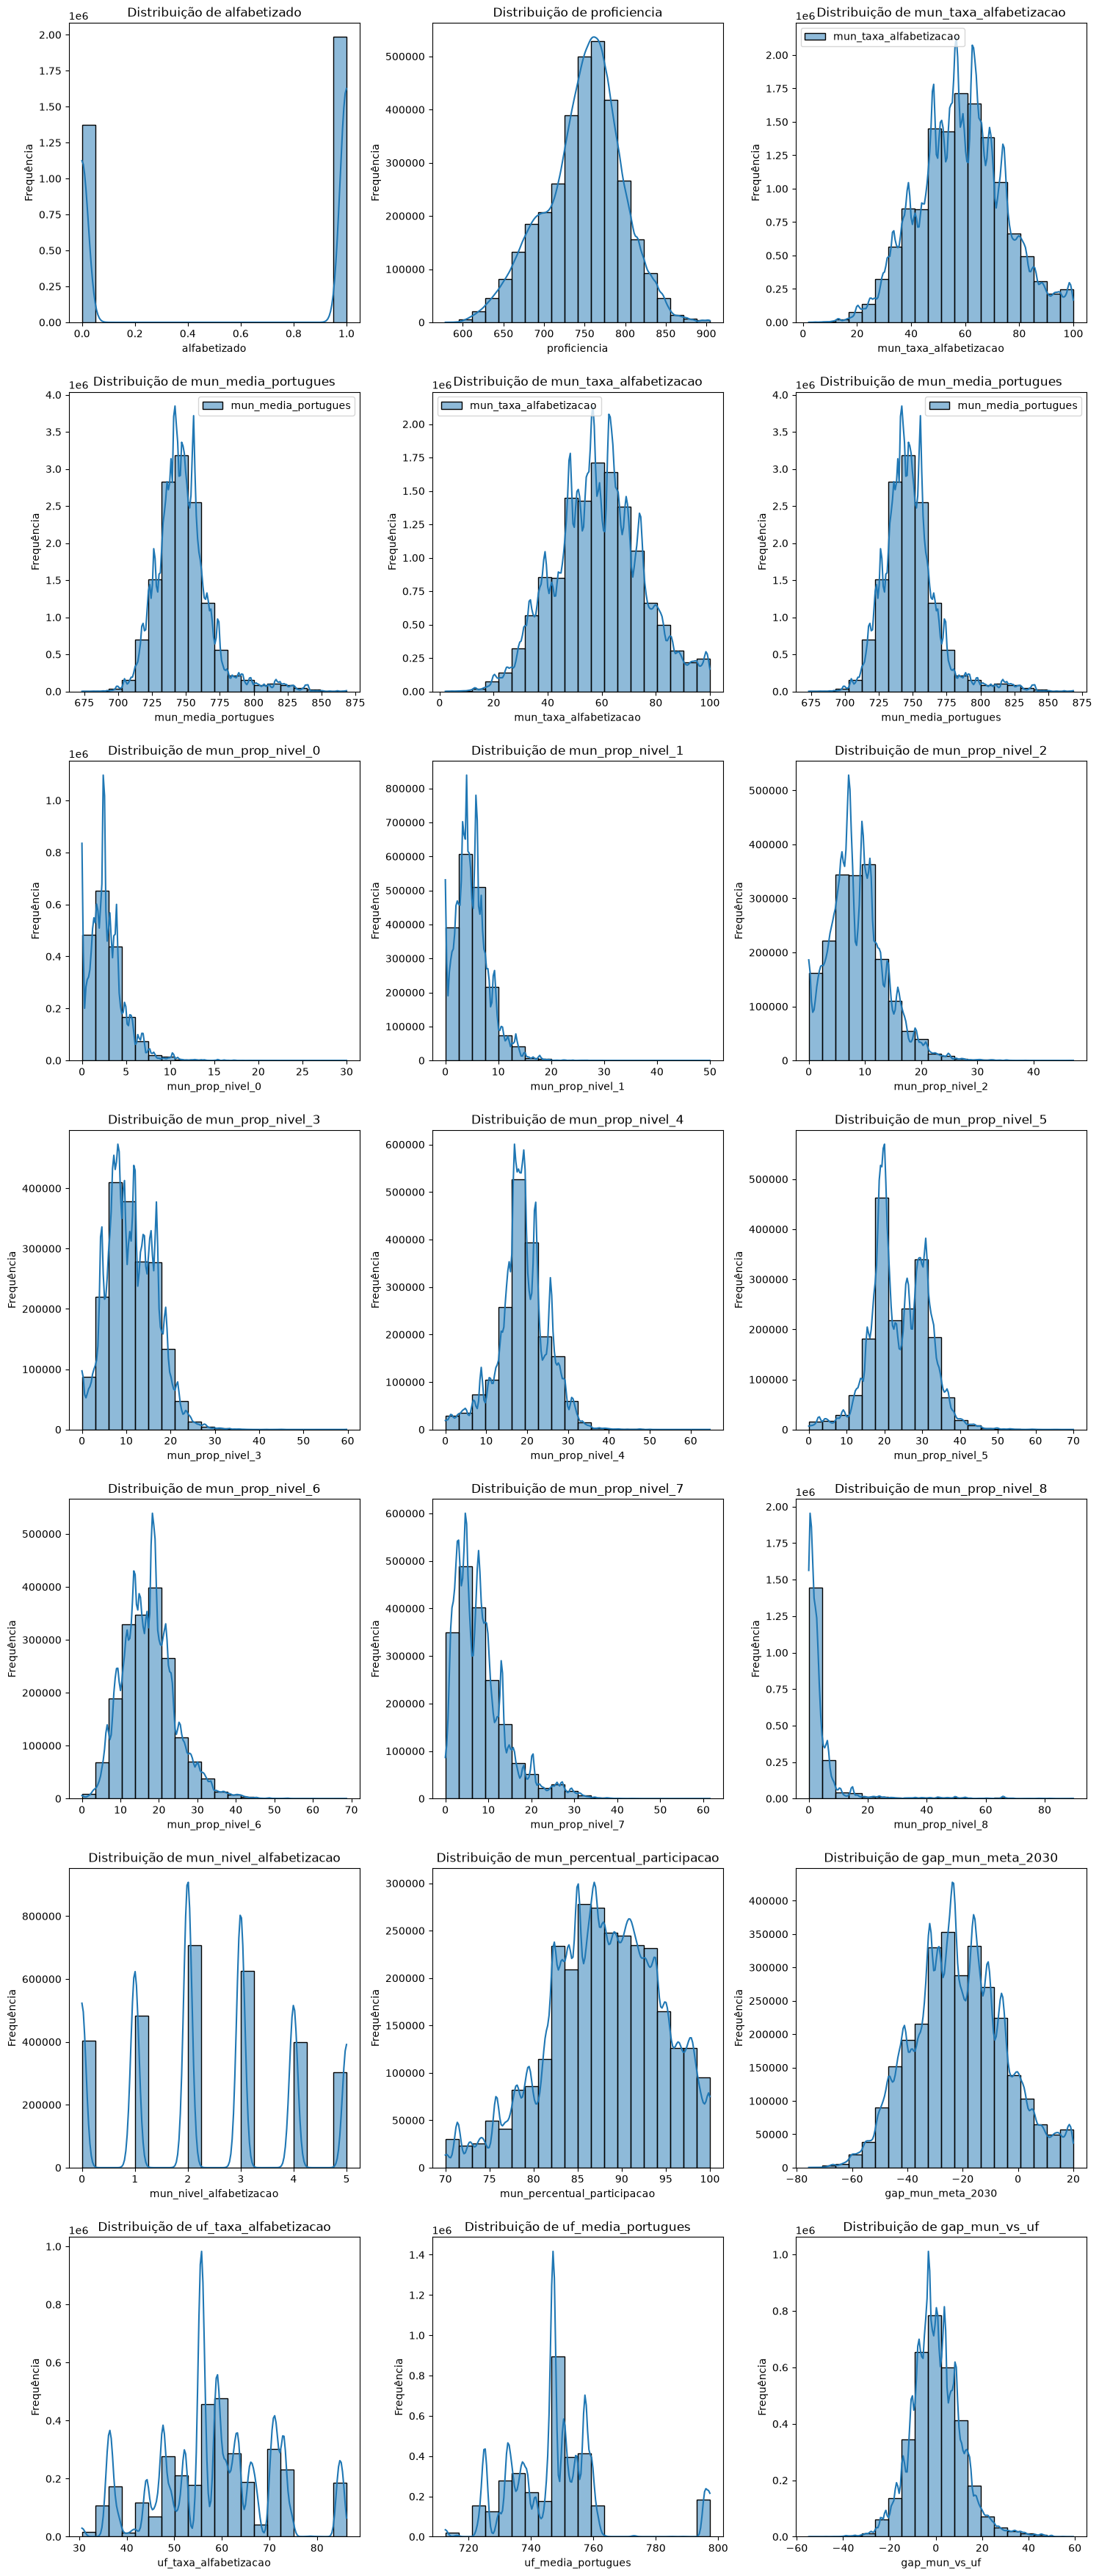

In [19]:
num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 2 # Adjust rows based on 3 columns per row

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(df_dist.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df_dist[column], bins=20, kde=True)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

Distribuicoes das features demonstram ser aproximadamente normais.
- A feature gap_mun_meta_2030 tem uma media de -22,39, em media grande parte dos municipios estao abaixo da media.
- Se comparamos media_portugues de municipio e UF, assim como taxa_alfabetizacao, percebemos que as feats de municipio trazem muito mais variabilidade, demonstrando que os dados a nivel UF suavizam demais as caracteristicas das feats.

## 3. Análisando Target

              contagem  percentual
alfabetizado                      
1              1984530       59.14
0              1371292       40.86


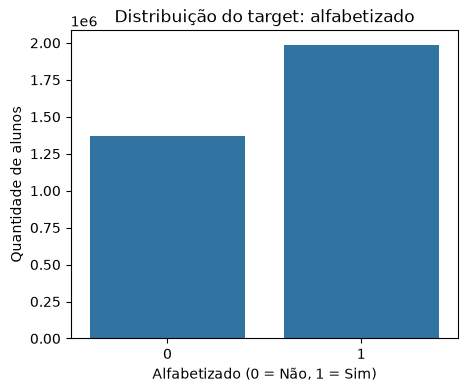

In [ ]:
# analisando target "alfabetizado"
contagem = df["alfabetizado"].value_counts()
percentual = df["alfabetizado"].value_counts(normalize=True) * 100

resumo_target = pd.DataFrame({"contagem": contagem, "percentual": percentual.round(2)})
print(resumo_target)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="alfabetizado")
plt.title("Distribuição do target: alfabetizado")
plt.xlabel("Alfabetizado (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade de alunos")
plt.show()

## 3.1 Observações sobre a Target
Proporcao da target esta em 59% de alfabetizados e 41% para nao alfabetizados, demonstrando desbalanceamento pouco impactante.

In [28]:
out_lista_variaveis = [
'alfabetizado','proficiencia',
'mun_taxa_alfabetizacao',
'mun_media_portugues','mun_prop_nivel_0','mun_prop_nivel_1',
'mun_prop_nivel_2', 'mun_prop_nivel_3', 'mun_prop_nivel_4',
'mun_prop_nivel_5', 'mun_prop_nivel_6',
'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
'mun_percentual_participacao', 'gap_mun_meta_2030',
'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'
]

df_dist_alf = df[out_lista_variaveis]

## 3.2 Comparando a Target com as feats

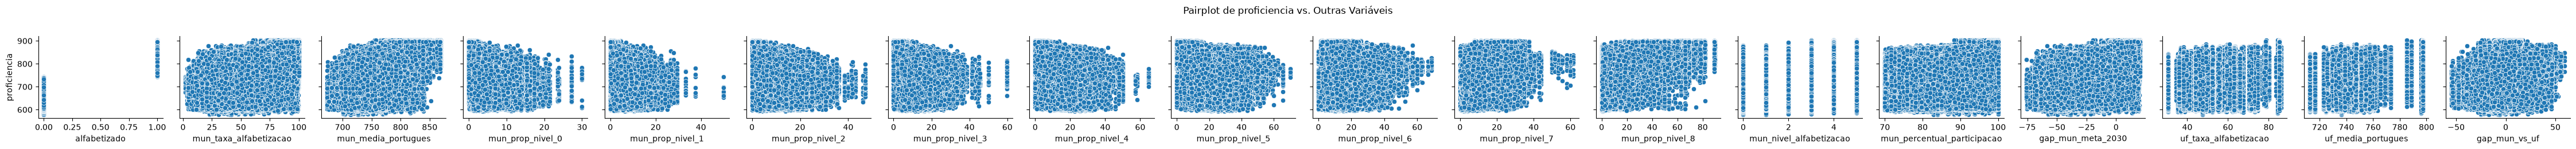

In [29]:
# comparando com target
sns.pairplot(df_dist_alf, y_vars=['proficiencia'], x_vars=df_dist_alf.drop('proficiencia', axis=1), kind='scatter')
plt.suptitle(f'Pairplot de proficiencia vs. Outras Variáveis', y=1.02)
plt.tight_layout()
plt.show()

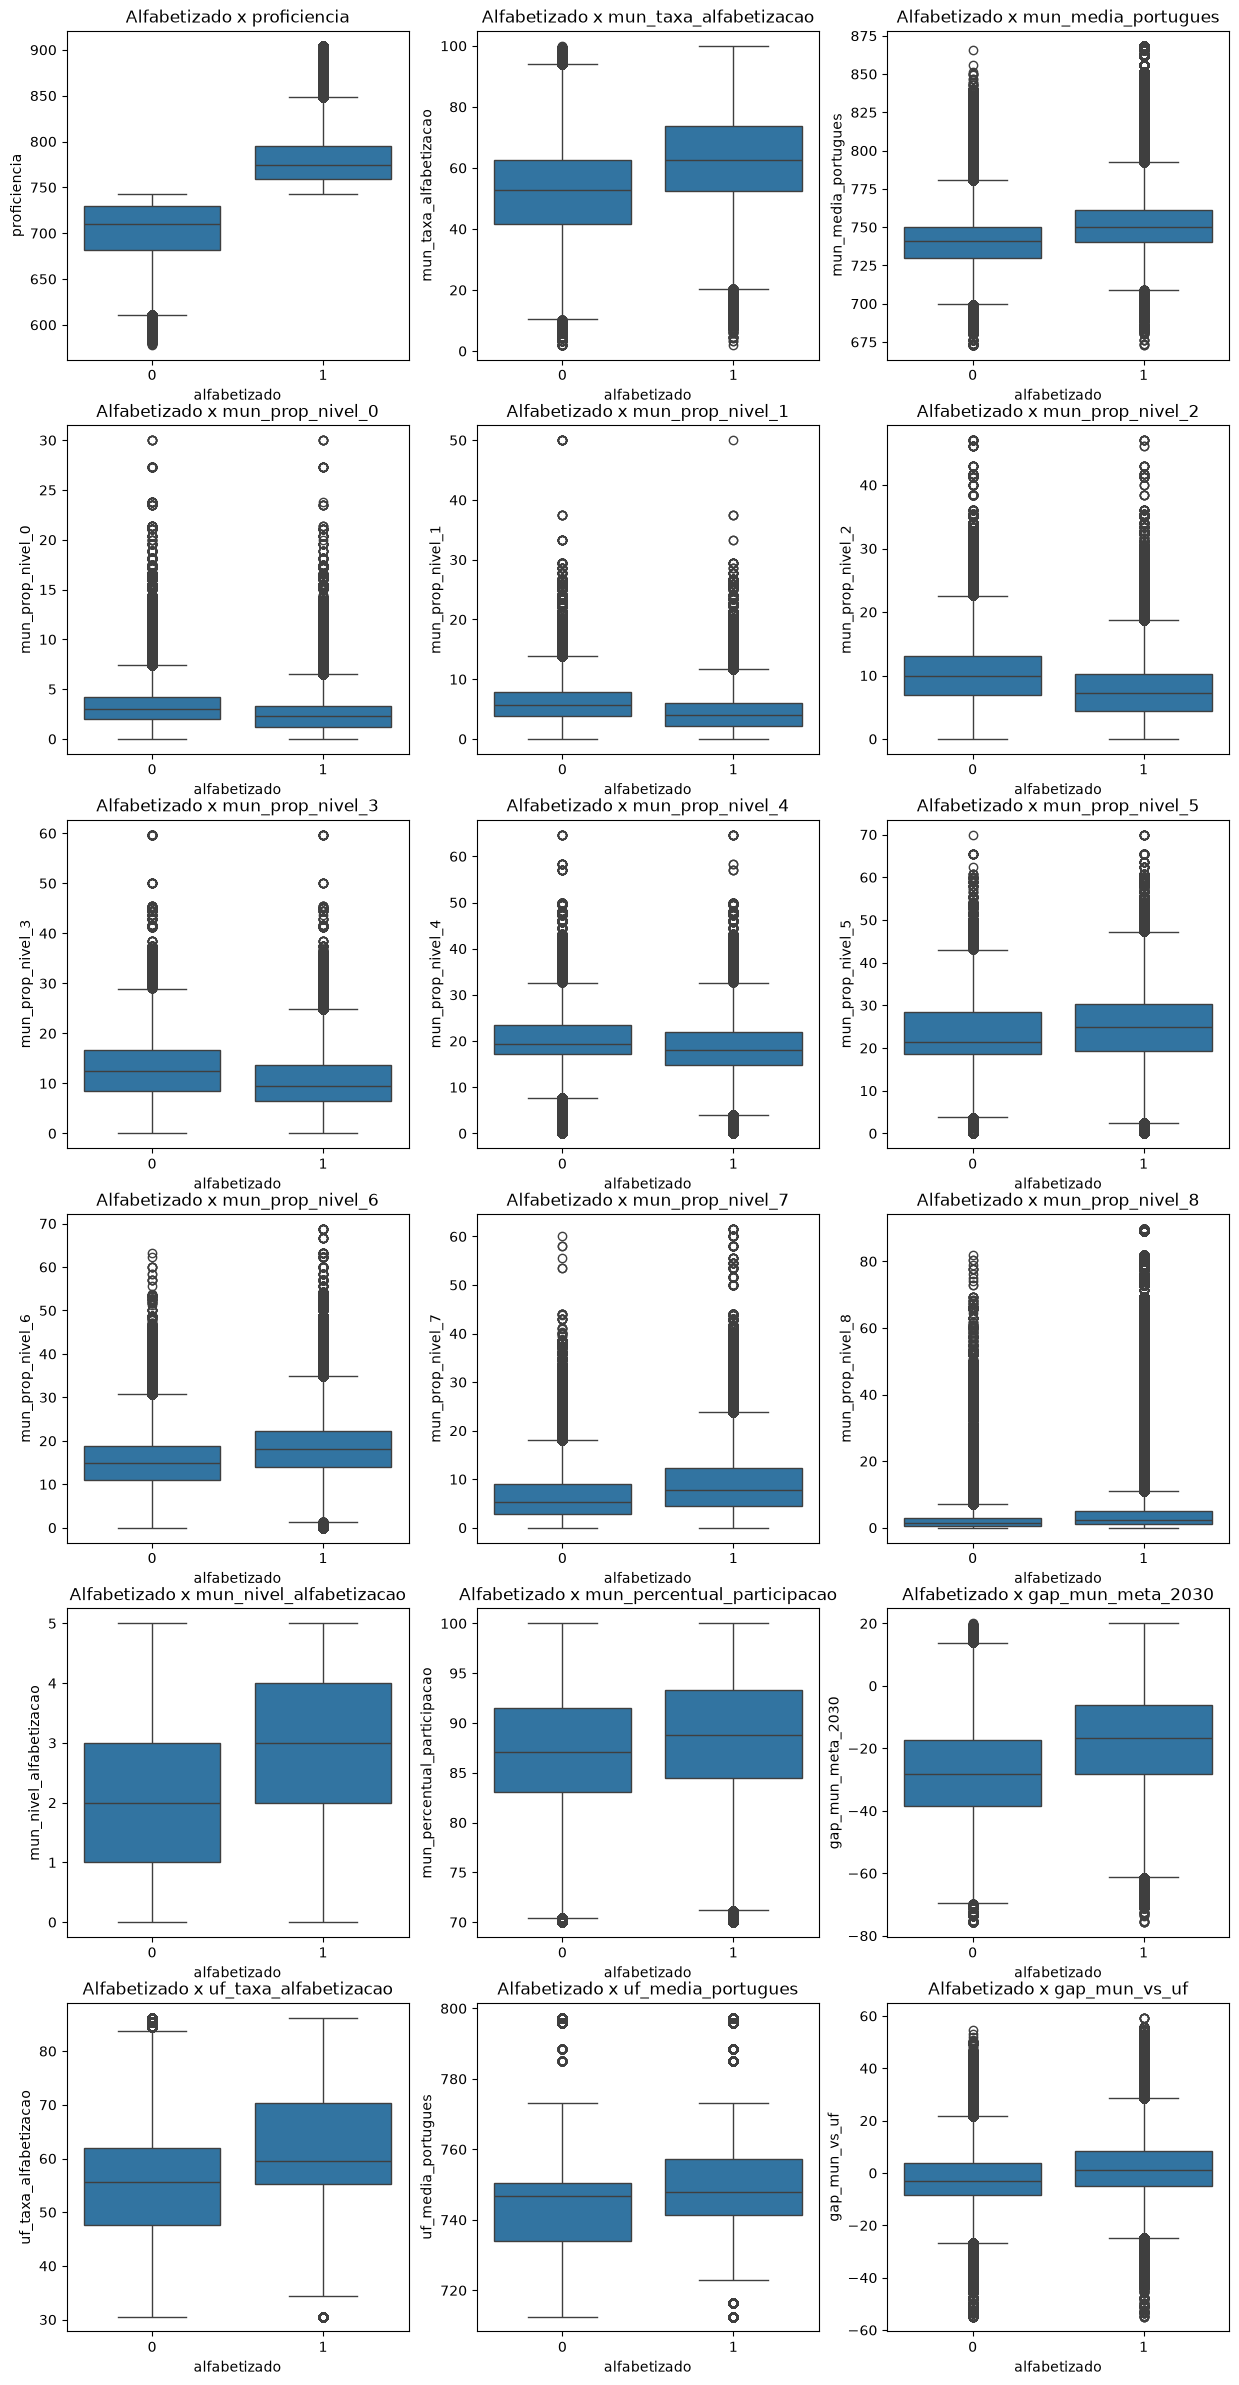

In [7]:
out_lista_variaveis = [
'proficiencia',
'mun_taxa_alfabetizacao',
'mun_media_portugues','mun_prop_nivel_0','mun_prop_nivel_1',
'mun_prop_nivel_2', 'mun_prop_nivel_3', 'mun_prop_nivel_4',
'mun_prop_nivel_5', 'mun_prop_nivel_6',
'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
'mun_percentual_participacao', 'gap_mun_meta_2030',
'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'
]

df_box = df[['alfabetizado'] + out_lista_variaveis]

num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 3

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(out_lista_variaveis):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(x='alfabetizado', y=column, data=df_box)
    plt.title(f'Alfabetizado x {column}')
    plt.xlabel('alfabetizado')
    plt.ylabel(column)

Alunos que tem proficiencia elevada, assim como medias de portugues, tem niveis de alfabetizacao e taxa de alfabetizacao altas.

In [15]:
for col in ["ano", "rede", "regiao"]:
    print(f"\n--- alfabetizado (%) por {col} ---")
    print((df.groupby(col)["alfabetizado"].mean() * 100).round(2))


--- alfabetizado (%) por ano ---
ano
2023    58.38
2024    59.75
Name: alfabetizado, dtype: float64

--- alfabetizado (%) por rede ---
rede
Estadual     62.09
Municipal    58.77
Name: alfabetizado, dtype: float64

--- alfabetizado (%) por regiao ---
regiao
Centro-Oeste    61.91
Nordeste        55.72
Norte           50.93
Sudeste         61.25
Sul             64.45
Name: alfabetizado, dtype: float64


O perceuntual de alfabetizados observado e baixo, ficando abaixo dos 60% dos alunos nos anos de 23 e 24. Durante os anos de 2023 e 2024 houve um cresimento de apenas 1,37 pontos percentuais.

A rede estadual, ligeiramente tem um percentual maior que a rede municipal.

Ja analisando por regiao, Norte e Nordeste aparecem como regioes mais precarias na proficiencia do aluno. As outras regioes ficam em patamares maiores, ainda assim preocupantes.

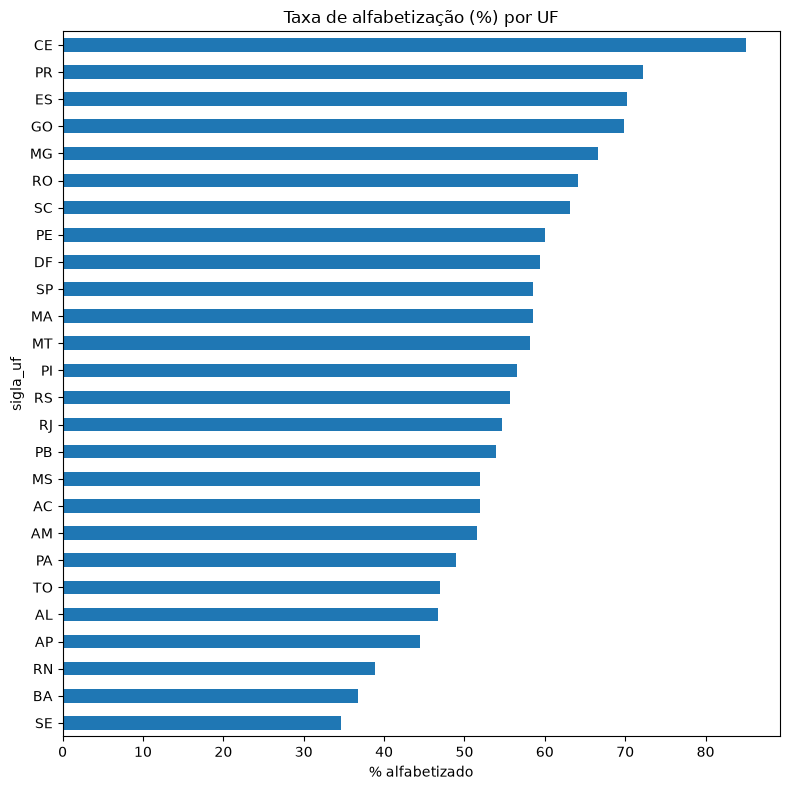

In [13]:
# analisando target em media por UF
por_uf = (df.groupby("sigla_uf")["alfabetizado"].mean() * 100).round(2).sort_values()

plt.figure(figsize=(8, 8))
por_uf.plot(kind="barh")
plt.title("Taxa de alfabetização (%) por UF")
plt.xlabel("% alfabetizado")
plt.tight_layout()
plt.show()

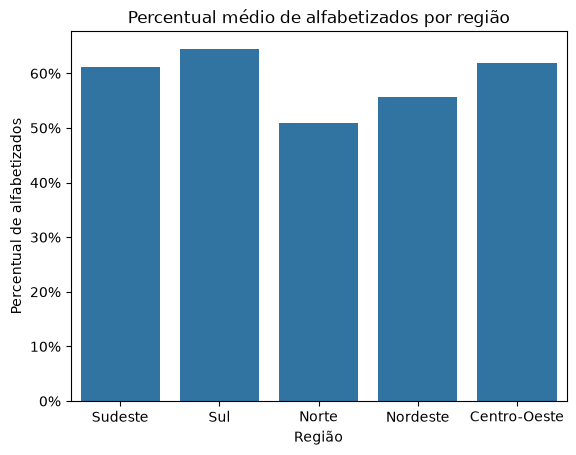

In [ ]:
# analisando regiao
sns.barplot(
    x='regiao',
    y='alfabetizado',
    data=df,
    estimator='mean',
    errorbar=None
)

plt.ylabel('Percentual de alfabetizados')
plt.xlabel('Região')
plt.title('Percentual médio de alfabetizados por região')

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1)
)

plt.show()


Apesar da media baixa de alfabetizados nas reigoes norte e nordeste do pais, tres estados estao no top 10 de maiores medias de alfabetizacao, CE, RO e PE. Reforcando a importancia das feats de municipios que podem trazer variabilidade para explicar a target.

## 4. Análise de Correlação

In [36]:
# correlcao
numericas = df.select_dtypes(include=[np.number]).columns.tolist()

colunas_remover = [
    'ano',
    'id_municipio',
    'id_aluno',
    'id_escola',
    'serie',
    'presenca',
]

numericas = [col for col in numericas if col not in colunas_remover]
correlacoes = df[numericas].corr(numeric_only=True)["alfabetizado"].sort_values(ascending=False)
correlacoes

alfabetizado                   1.000000
proficiencia                   0.795599
gap_mun_meta_2030              0.331367
mun_taxa_alfabetizacao         0.325776
mun_nivel_alfabetizacao        0.321746
mun_media_portugues            0.303625
mun_prop_nivel_6               0.252966
uf_taxa_alfabetizacao          0.243265
uf_media_portugues             0.224940
mun_prop_nivel_7               0.222570
gap_mun_vs_uf                  0.218308
mun_prop_nivel_8               0.169538
mun_percentual_participacao    0.123502
mun_prop_nivel_5               0.102072
preenchimento_caderno          0.022610
caderno                       -0.000501
peso_aluno                    -0.048520
mun_prop_nivel_4              -0.197348
mun_prop_nivel_0              -0.220293
mun_prop_nivel_3              -0.246732
mun_prop_nivel_1              -0.268905
mun_prop_nivel_2              -0.275615
Name: alfabetizado, dtype: float64

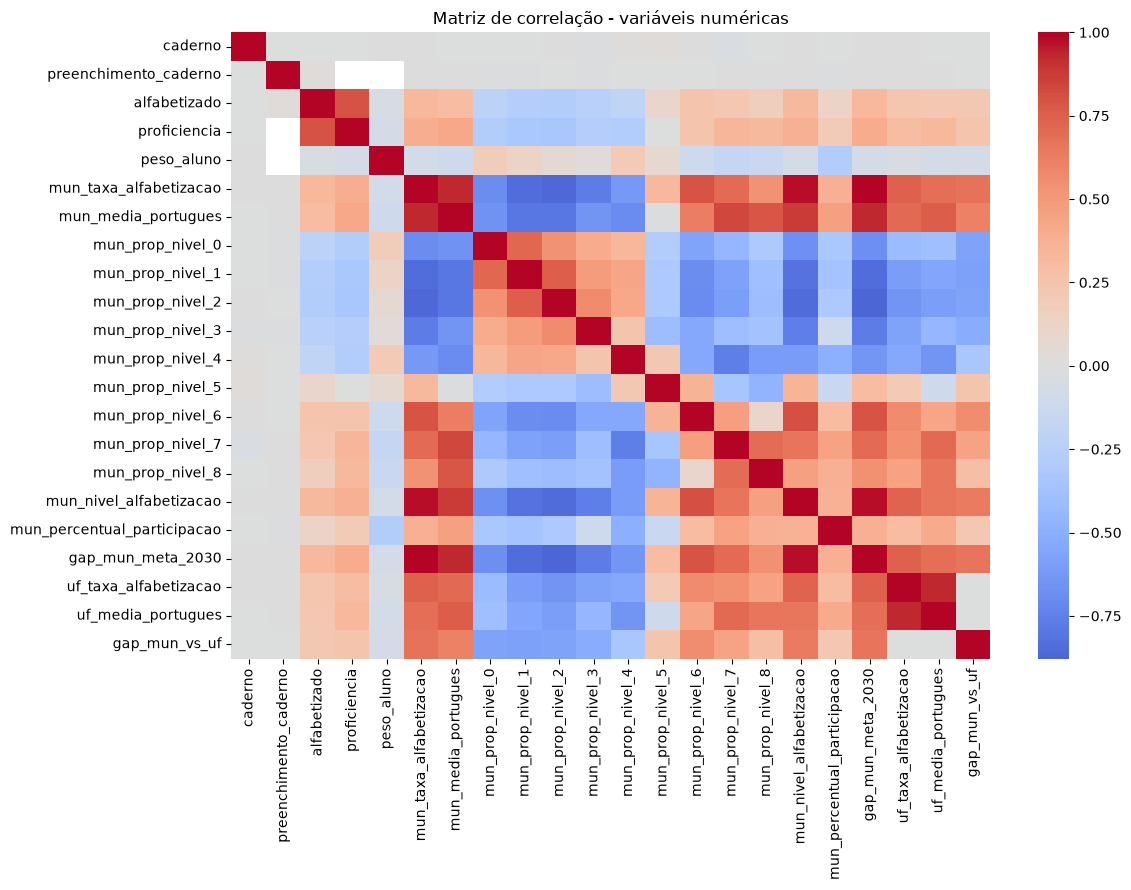

In [37]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[numericas].corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlação - variáveis numéricas")
plt.tight_layout()
plt.show()

Correlacao forte entre as feats proficiencia, taxa de alfabetizacao e nivel alfabetizacao.
Investigar possivel leakage.


Feats caderno e preenchimento caderno devem ser retiradas, sao apenas ruidos, assim como as feats comecadas com `id`, `serie` que tem somente conteudo "2" e `presenca` que tem todo conteudo igual a "1".

## 5. Investigando leakage

In [27]:
print(df.groupby("mun_nivel_alfabetizacao")["mun_taxa_alfabetizacao"].describe())

                            count       mean       std    min    25%    50%  \
mun_nivel_alfabetizacao                                                       
0.0                      403623.0  33.252075  5.609165   4.35  30.51  34.52   
1.0                      482228.0  45.707743  2.739112  40.00  43.63  46.31   
2.0                      706439.0  54.970622  2.827897  50.00  52.37  55.08   
3.0                      624778.0  65.079243  2.767552  60.00  62.82  64.81   
4.0                      399013.0  74.456701  2.744525  70.00  72.21  74.22   
5.0                      302212.0  88.277793  6.188930  80.00  82.61  86.91   

                           75%     max  
mun_nivel_alfabetizacao                 
0.0                      37.71   40.00  
1.0                      48.21   50.00  
2.0                      57.15   91.67  
3.0                      67.46   70.00  
4.0                      76.41   80.00  
5.0                      93.55  100.00  


A feat `mun_nivel_alfabetizacao` e formada por grupos bem estabelecidos de `mun_taxa_alfabetizacao`, demonstrando multicolinearidade, entao podemos descartar  `mun_nivel_alfabetizacao`.

In [ ]:
# investigando possivel leakage de proficiencia
print("Nulos em proficiencia, por classe de alfabetizado:")
print(df.groupby("alfabetizado")["proficiencia"].apply(lambda s: s.isnull().mean() * 100).round(2))

print("\nEstatísticas de proficiencia por classe de alfabetizado:")
df.groupby("alfabetizado")["proficiencia"].describe()

Nulos em proficiencia, por classe de alfabetizado:
alfabetizado
0    0.09
1    0.00
Name: proficiencia, dtype: float64

Estatísticas de proficiencia por classe de alfabetizado:


,count,mean,std,min,25%,50%,75%,max
alfabetizado,,,,,,,,
0,1370107.0,702.815370,31.255570,578.46,681.824086,709.522218,729.443687,742.999819
1,1984530.0,779.837187,27.026412,743.00,758.968725,774.333107,794.690000,904.382031


In [ ]:
max_prof_nao = df.loc[df["alfabetizado"] == 0, "proficiencia"].max()
min_prof_sim = df.loc[df["alfabetizado"] == 1, "proficiencia"].min()

print(f"Maior proficiencia entre os NÃO alfabetizados: {max_prof_nao}")
print(f"Menor proficiencia entre os alfabetizados:      {min_prof_sim}")

if max_prof_nao < min_prof_sim:
    print("\n>>>  separação perfeita por um ponto de corte. Forte indício de data leakage.")
else:
    print("\n>>> Há sobreposição entre as classes - proficiencia não separa 100% sozinha.")

Maior proficiencia entre os NÃO alfabetizados: 742.9998188
Menor proficiencia entre os alfabetizados:      743.0

>>> ATENÇÃO: separação perfeita por um ponto de corte. Forte indício de data leakage.


Na propria documentacao e descrito que `alfabetizado` deriva do corte deterministico de `proficiencia`, logo nao podemos usa-la como variavel explicativa, caso contrario o modelo decora regra da target.

""Alfabetizado -> Indica se o aluno, mediante o resultado da avaliação estadual, é considerado alfabetizado. Será considerado alfabetizado o aluno que atingir a proficiência maior ou igual a 743, na escala do SAEB para o 2º ano do ensino fundamental, na prova de Língua Portuguesa (LP). Nesse ponto da escala, os aluno serão capazes de:
- Ler palavras, frases e textos curtos;
- Localizar informações explícitas em textos curtos (até seis linhas), como em bilhete, crônica e fragmento de conto infantil;
- Inferir informações em textos que articulam linguagem verbal e não verbal, como em tirinhas e cartazes;
- Escrever ortograficamente palavras com regularidades diretas entre fonemas e letras;
- Escrever textos que circulam na vida cotidiana, ainda que com desvios ortográficos ou de segmentação."
"

In [ ]:
# investigando possivel leakage em taxa_alfabetizacao

In [40]:
df['mun_taxa_alfabetizacao'].describe()

count    3.355641e+06
mean     5.881615e+01
std      1.611849e+01
min      2.120000e+00
25%      4.818000e+01
50%      5.854000e+01
75%      6.922000e+01
max      1.000000e+02
Name: mun_taxa_alfabetizacao, dtype: float64

In [41]:
df['mun_taxa_alfabetizacao'].head(10)

0    54.58
1    59.54
2    53.75
3    48.56
4    48.56
5    41.54
6    85.70
7    70.47
8    63.84
9    47.49
Name: mun_taxa_alfabetizacao, dtype: float64

In [42]:
df['peso_aluno'].head(10)

0    0.310110
1    0.452510
2    0.545775
3    0.585886
4    0.585886
5    0.607895
6    0.626172
7    0.661227
8    0.666667
9    0.682567
Name: peso_aluno, dtype: float64

In [43]:
df['peso_alfabetizado'] = df['peso_aluno'] * df['alfabetizado']

In [44]:
taxa_calculada = (
    df.groupby(['ano', 'id_municipio'])
      .agg(
          soma_peso_alfabetizado=('peso_alfabetizado', 'sum'),
          soma_peso=('peso_aluno', 'sum')
      )
      .reset_index()
)

In [45]:
taxa_calculada

,ano,id_municipio,soma_peso_alfabetizado,soma_peso
0,2023,1100015,163.949817,253.999998
1,2023,1100023,848.363548,1361.779170
2,2023,1100031,58.043591,84.000000
3,2023,1100049,604.315819,953.589420
4,2023,1100056,141.067880,241.000000
...,...,...,...,...
10383,2024,5222005,146.880000,164.120000
10384,2024,5222054,80.000000,95.000000
10385,2024,5222203,48.000000,61.000000
10386,2024,5222302,58.050000,73.060000


In [46]:
taxa_calculada['taxa'] = (
    taxa_calculada['soma_peso_alfabetizado']
    / taxa_calculada['soma_peso']
    * 100
)

In [47]:
taxa_calculada

,ano,id_municipio,soma_peso_alfabetizado,soma_peso,taxa
0,2023,1100015,163.949817,253.999998,64.547173
1,2023,1100023,848.363548,1361.779170,62.298173
2,2023,1100031,58.043591,84.000000,69.099513
3,2023,1100049,604.315819,953.589420,63.372748
4,2023,1100056,141.067880,241.000000,58.534390
...,...,...,...,...,...
10383,2024,5222005,146.880000,164.120000,89.495491
10384,2024,5222054,80.000000,95.000000,84.210526
10385,2024,5222203,48.000000,61.000000,78.688525
10386,2024,5222302,58.050000,73.060000,79.455242


In [48]:
taxa_original = (
    df.groupby(['ano', 'id_municipio'])
      ['mun_taxa_alfabetizacao']
      .first()
      .reset_index()
)

In [49]:
comparacao = taxa_calculada.merge(
    taxa_original,
    on=['ano', 'id_municipio'],
    how='inner'
)

In [50]:
comparacao

,ano,id_municipio,soma_peso_alfabetizado,soma_peso,taxa,mun_taxa_alfabetizacao
0,2023,1100015,163.949817,253.999998,64.547173,64.55
1,2023,1100023,848.363548,1361.779170,62.298173,62.30
2,2023,1100031,58.043591,84.000000,69.099513,69.10
3,2023,1100049,604.315819,953.589420,63.372748,62.51
4,2023,1100056,141.067880,241.000000,58.534390,58.53
...,...,...,...,...,...,...
10383,2024,5222005,146.880000,164.120000,89.495491,89.50
10384,2024,5222054,80.000000,95.000000,84.210526,84.21
10385,2024,5222203,48.000000,61.000000,78.688525,78.69
10386,2024,5222302,58.050000,73.060000,79.455242,79.46


In [52]:
comparacao['diferenca'] = (
    comparacao['taxa']
    - comparacao['mun_taxa_alfabetizacao']
).abs()

In [53]:
comparacao['diferenca'].describe()

count    10387.000000
mean         1.044492
std          3.521602
min          0.000000
25%          0.002135
50%          0.004557
75%          0.027859
max         59.852957
Name: diferenca, dtype: float64

A taxa_alfabetizacao tambem deriva da propria target.

## Observações finais:
- Não será possível utilizar as fets presenca, preenchimento_caderno, proficiencia, mun_taxa_alfabetizacao, mun_media_portugues, mun_prop_nivel_...0 a 8, mun_nivel_alfabetizacao, mun_percentual_participacao, gap_mun_meta_2030, uf_taxa_alfabetizacao	, uf_media_portugues, gap_mun_vs_uf

- Iremos utilizar as feats ano, id_municipio, id_escola, id_aluno, rede, alfabetizado, peso_aluno, sigla_uf e regiao da tabela `alunos` enriquecidas com feats do cadastro unico e Censo Escolar. Provenientes do notebook `contrucao_master_table.py` que chamamos de master table.

In [58]:
# # mostra todas as colunas do DataFrame sem truncar
# pd.set_option("display.max_columns", None)
# pd.set_option("display.expand_frame_repr", False)
# pd.set_option("display.width", 1000)

# df

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,sigla_uf,regiao,mun_taxa_alfabetizacao,mun_media_portugues,mun_prop_nivel_0,mun_prop_nivel_1,mun_prop_nivel_2,mun_prop_nivel_3,mun_prop_nivel_4,mun_prop_nivel_5,mun_prop_nivel_6,mun_prop_nivel_7,mun_prop_nivel_8,mun_nivel_alfabetizacao,mun_percentual_participacao,gap_mun_meta_2030,uf_taxa_alfabetizacao,uf_media_portugues,gap_mun_vs_uf,populacao_municipio,mun_perc_pop_pobreza
0,2023,3300704,60025977,33014516,1,2,Municipal,1,1,1,746.319800,0.310110,RJ,Sudeste,54.58,742.9705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,77.39,-25.42,52.13,737.3032,2.45,238166.0,34.57
1,2023,3121605,60021971,31008498,1,2,Municipal,1,1,1,772.288100,0.452510,MG,Sudeste,59.54,748.5891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,91.70,-20.46,58.74,750.4243,0.80,49353.0,41.28
2,2023,3157807,60018571,31151092,1,2,Estadual,1,1,1,776.191000,0.545775,MG,Sudeste,53.75,745.1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.65,756.3436,-9.90,229483.0,32.33
3,2023,4204806,60035456,42032360,1,2,Municipal,1,1,1,764.075514,0.585886,SC,Sul,48.56,731.6748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,79.47,-31.44,62.04,747.7686,-13.48,41512.0,26.35
4,2023,4204806,60035456,42032357,1,2,Municipal,1,1,1,772.580780,0.585886,SC,Sul,48.56,731.6748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,79.47,-31.44,62.04,747.7686,-13.48,41512.0,26.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3355817,2024,4322400,60038978,43098836,9,2,Municipal,1,1,0,697.423980,2.000000,RS,Sul,47.30,735.1702,2.51,6.44,16.68,12.62,20.63,22.13,14.29,3.64,1.06,1.0,74.64,-32.70,44.23,733.9263,3.07,120885.0,30.64
3355818,2024,2602902,60013156,26035176,9,2,Municipal,1,1,0,732.780000,2.380000,PE,Nordeste,50.72,737.7800,2.73,5.05,9.78,19.63,17.16,28.06,14.31,2.67,0.62,2.0,91.65,-29.28,60.76,747.2800,-10.04,216969.0,45.48
3355819,2024,4314902,60038096,43065853,9,2,Estadual,1,1,0,667.897123,2.400000,RS,Sul,31.30,718.9763,6.96,10.72,18.93,18.82,17.95,13.82,8.22,3.29,1.28,NaN,NaN,NaN,45.63,734.9670,-14.33,1389322.0,22.64
3355820,2024,3167202,60019847,31182116,9,2,Municipal,1,1,1,761.840000,2.430000,MG,Sudeste,60.35,747.0200,1.53,4.49,8.48,9.19,22.91,31.10,15.78,4.61,1.91,3.0,87.26,-19.65,71.45,757.4100,-11.10,237931.0,20.62


# 6. Leitura da master table alunos_enriquecido

In [59]:
df_master = pd.read_parquet(f"../data/silver/alunos_enriquecido/alunos_enriquecido.parquet")

In [60]:
print(f'tamanho do nosso dataset (Linhas, Colunas): {df_master.shape}')

tamanho do nosso dataset (Linhas, Colunas): (3355822, 45)


In [61]:
df_master.head()

,ano,id_municipio,id_escola,id_aluno,rede,alfabetizado,ANO,pct_in_biblioteca,pct_in_sala_leitura,pct_in_internet,pct_in_laboratorio_informatica,pct_in_agua_potavel,pct_in_energia_inexistente,pct_in_esgoto_inexistente,pct_in_alimentacao,pct_in_acessibilidade_corrimao,pct_in_acessibilidade_elevador,pct_in_acessibilidade_pisos_tateis,pct_in_acessibilidade_vao_livre,pct_in_acessibilidade_rampas,pct_in_acessibilidade_sinal_sonoro,pct_in_acessibilidade_sinal_tatil,pct_in_acessibilidade_sinal_visual,pct_in_banheiro_pne,pct_in_material_ped_infantil,pct_in_material_ped_cientifico,pct_in_material_ped_jogos,pct_in_material_ped_artisticas,pct_in_material_ped_multimidia,pct_in_educacao_indigena,qt_mat_bas_media,qt_salas_media,n_escolas,qtd_pes_pob_media,qtd_pes_baixa_renda_media,qtd_pes_acima_meio_sm_media,qtd_pes_pob_min,qtd_pes_baixa_renda_min,qtd_pes_acima_meio_sm_min,qtd_pes_pob_max,qtd_pes_baixa_renda_max,qtd_pes_acima_meio_sm_max,qtd_pes_pob_desvio_padrao,qtd_pes_baixa_renda_desvio_padrao,qtd_pes_acima_meio_sm_desvio_padrao
0,2023,330070,60025977,33014516,Municipal,1,2023,0.357143,0.649351,0.993506,0.311688,0.993506,0.0,0.00000,0.720779,0.422078,0.032468,0.116883,0.461039,0.538961,0.038961,0.032468,0.155844,0.636364,0.545455,0.233766,0.889610,0.603896,0.454545,0.0,328.099338,10.272727,173,62943.5,19228.7,15008.3,59740,16977,9130,68077,20868,19074,3069.361036,1507.987699,4148.806041
1,2023,312160,60021971,31008498,Municipal,1,2023,0.804878,0.121951,0.975610,0.487805,0.975610,0.0,0.02439,0.853659,0.341463,0.073171,0.048780,0.365854,0.634146,0.195122,0.000000,0.097561,0.536585,0.390244,0.268293,0.756098,0.365854,0.609756,0.0,277.195122,10.463415,91,12778.2,8724.7,7293.5,11687,8354,4478,14705,9407,9245,1315.642370,380.101171,1992.772510
2,2023,315780,60018571,31151092,Estadual,1,2023,0.765432,0.197531,1.000000,0.358025,1.000000,0.0,0.00000,0.802469,0.592593,0.037037,0.111111,0.506173,0.728395,0.037037,0.049383,0.123457,0.851852,0.580247,0.111111,0.839506,0.469136,0.345679,0.0,576.716049,14.444444,99,51560.3,26492.6,20555.5,46111,25722,10641,60477,27113,26625,6171.184418,489.561527,6795.470849
3,2023,420480,60035456,42032360,Municipal,1,2023,0.777778,0.083333,1.000000,0.583333,1.000000,0.0,0.00000,0.861111,0.611111,0.055556,0.166667,0.805556,0.750000,0.055556,0.111111,0.194444,0.694444,0.583333,0.222222,0.861111,0.527778,0.638889,0.0,319.225806,11.027778,39,6624.1,4978.6,5802.6,5868,4693,3917,7909,5432,6906,869.306550,278.190662,1242.301198
4,2023,420480,60035456,42032357,Municipal,1,2023,0.777778,0.083333,1.000000,0.583333,1.000000,0.0,0.00000,0.861111,0.611111,0.055556,0.166667,0.805556,0.750000,0.055556,0.111111,0.194444,0.694444,0.583333,0.222222,0.861111,0.527778,0.638889,0.0,319.225806,11.027778,39,6624.1,4978.6,5802.6,5868,4693,3917,7909,5432,6906,869.306550,278.190662,1242.301198


## 6.1 Analisando nulos

In [62]:
nulos = df_master.isnull().mean().sort_values(ascending=False) * 100
nulos = nulos[nulos > 0]
print("Percentual de nulos por coluna:")
nulos

Percentual de nulos por coluna:


Series([], dtype: float64)

# 7. Análise Descritiva

In [63]:
df_master.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,3355822.0,NaN,NaN,NaN,2023.552104,0.497278,2023.0,2023.0,2024.0,2024.0,2024.0
id_municipio,3355822.0,NaN,NaN,NaN,321567.078673,103347.348961,110001.0,251050.0,317010.0,410690.0,530010.0
id_escola,3355822.0,NaN,NaN,NaN,60021802.2615,12549.161898,60000001.0,60011249.0,60022103.0,60032799.75,60042811.0
id_aluno,3355822.0,NaN,NaN,NaN,32097807.577066,10333965.966297,11000001.0,25025676.0,31189940.0,41041128.0,53027700.0
rede,3355822,2,Municipal,2983123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alfabetizado,3355822.0,NaN,NaN,NaN,0.591369,0.491581,0.0,0.0,1.0,1.0,1.0
ANO,3355822,2,2024,1852764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pct_in_biblioteca,3355822.0,NaN,NaN,NaN,0.431631,0.223349,0.0,0.239437,0.444417,0.6,1.0
pct_in_sala_leitura,3355822.0,NaN,NaN,NaN,0.29761,0.172776,0.0,0.171779,0.27907,0.404692,1.0
pct_in_internet,3355822.0,NaN,NaN,NaN,0.949953,0.119313,0.048387,0.970588,0.994524,1.0,1.0


In [66]:
colunas_df_master = [
    col for col in df_master.columns
    if col not in ['ano', 'ANO', 'id_municipio', 'id_escola', 'id_aluno', 'rede']
]

df_dist = df_master[colunas_df_master]

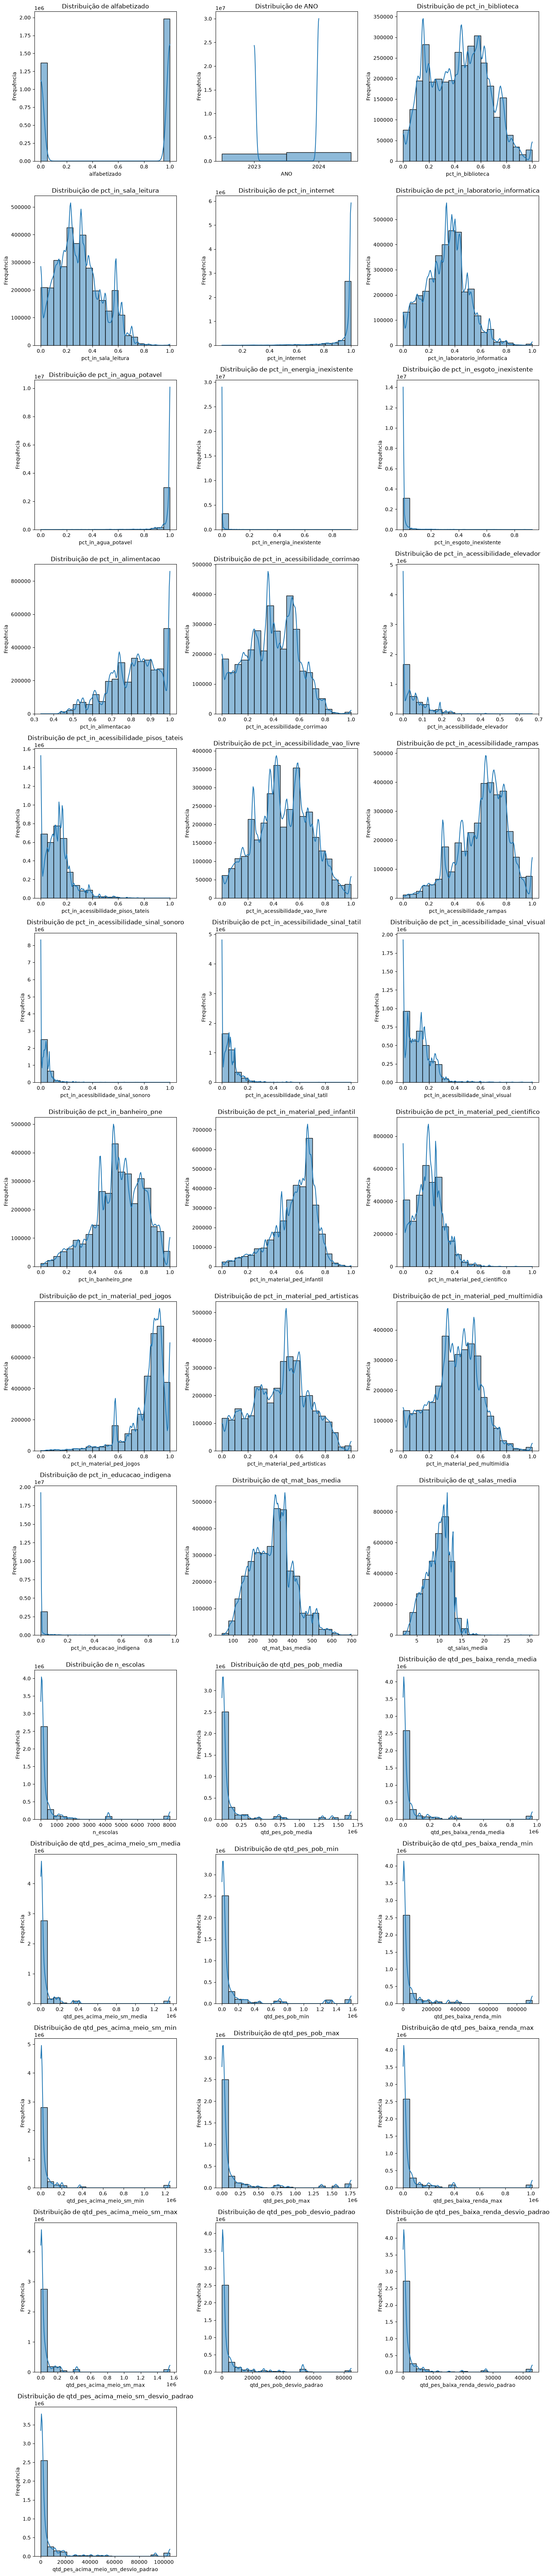

In [67]:
num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 2 # Adjust rows based on 3 columns per row

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(df_dist.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df_dist[column], bins=20, kde=True)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

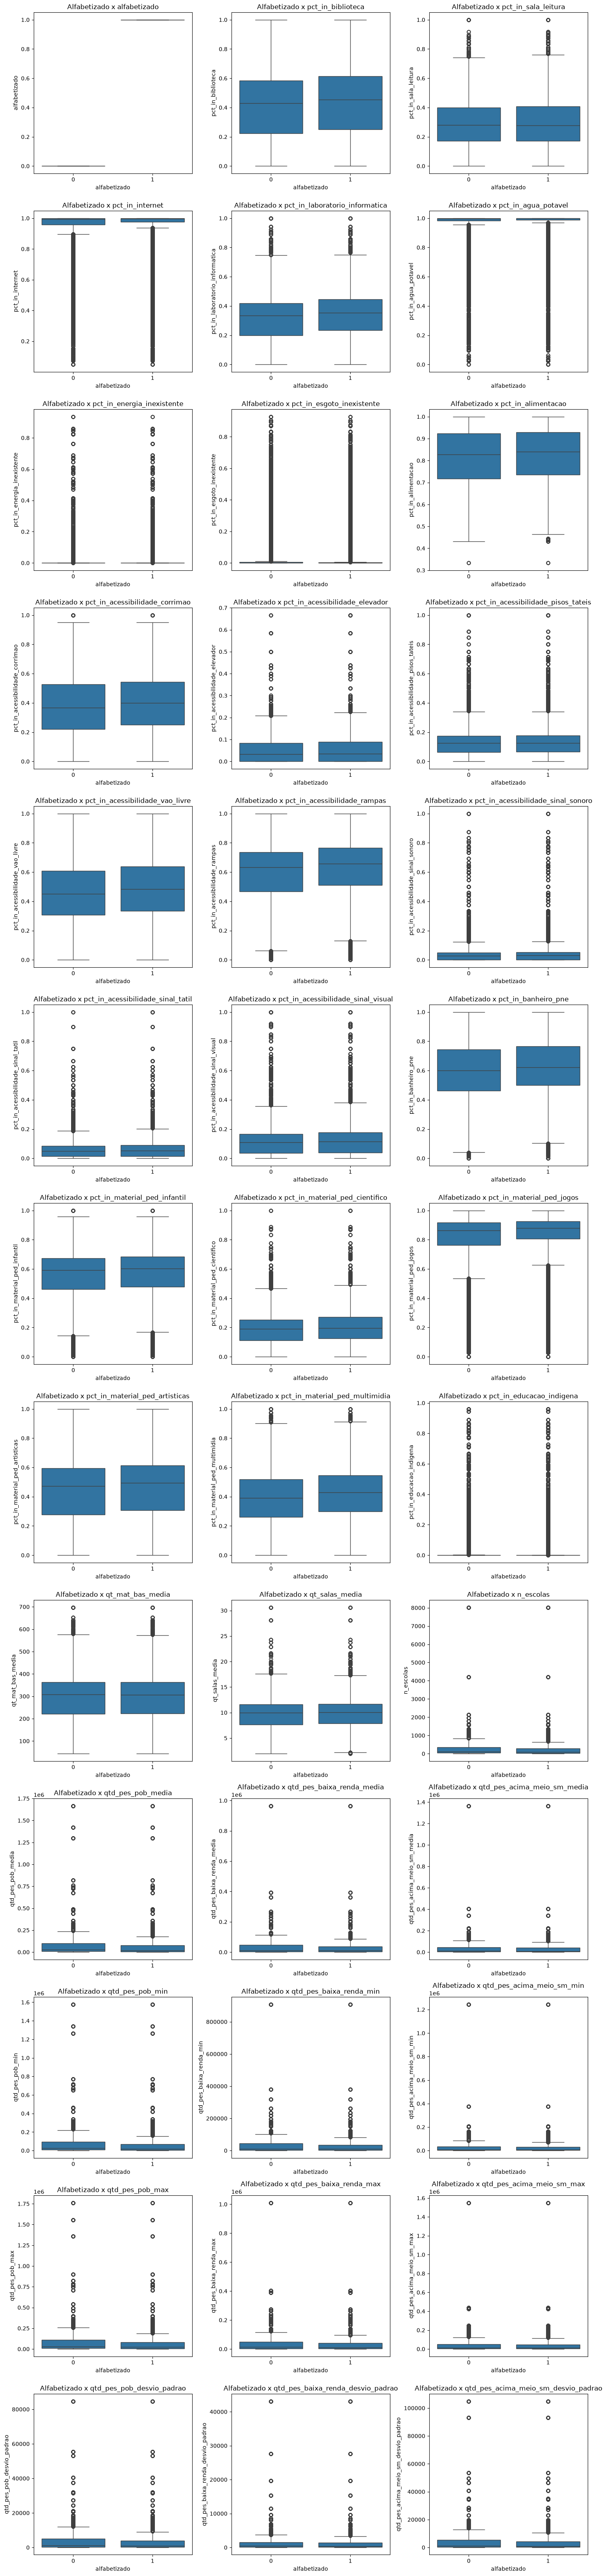

In [77]:
colunas_df_master = [
    col for col in df_master.columns
    if col not in ['ano', 'ANO', 'id_municipio', 'id_escola', 'id_aluno', 'rede']
]

df_box = df_master[colunas_df_master]

num_cols = len(df_box.columns)
num_rows = (num_cols + 2) // 3

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(colunas_df_master):

    plt.subplot(num_rows, 3, i + 1)

    sns.boxplot(x='alfabetizado', y=column, data=df_box)

    plt.title(f'Alfabetizado x {column}')

    plt.xlabel('alfabetizado')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

In [78]:
# correlcao
numericas = df_master.select_dtypes(include=[np.number]).columns.tolist()

colunas_remover = [
    'ano',
    'ANO',
    'id_municipio',
    'id_aluno',
    'id_escola',
]

numericas = [col for col in numericas if col not in colunas_remover]
correlacoes = df_master[numericas].corr(numeric_only=True)["alfabetizado"].sort_values(ascending=False)
correlacoes

alfabetizado                           1.000000
pct_in_laboratorio_informatica         0.087498
pct_in_material_ped_jogos              0.080017
pct_in_acessibilidade_rampas           0.075450
pct_in_material_ped_multimidia         0.074819
pct_in_acessibilidade_corrimao         0.071515
pct_in_banheiro_pne                    0.063115
pct_in_biblioteca                      0.062038
pct_in_internet                        0.059719
pct_in_material_ped_artisticas         0.058854
pct_in_acessibilidade_vao_livre        0.053458
pct_in_material_ped_cientifico         0.053307
pct_in_agua_potavel                    0.052269
pct_in_material_ped_infantil           0.051088
pct_in_alimentacao                     0.049255
pct_in_acessibilidade_sinal_visual     0.035062
qt_salas_media                         0.034859
pct_in_acessibilidade_sinal_sonoro     0.024264
pct_in_acessibilidade_sinal_tatil      0.021313
pct_in_acessibilidade_elevador         0.018247
pct_in_acessibilidade_pisos_tateis     0

In [ ]:
# correlcao
numericas = df_master.select_dtypes(include=[np.number]).columns.tolist()

colunas_remover = [
    'ano',
    'ANO',
    'id_municipio',
    'id_aluno',
    'id_escola',
]

numericas = [col for col in numericas if col not in colunas_remover]
correlacoes = df_master[numericas].corr(numeric_only=True)["alfabetizado"].sort_values(ascending=False)
correlacoes

alfabetizado                           1.000000
pct_in_laboratorio_informatica         0.087498
pct_in_material_ped_jogos              0.080017
pct_in_acessibilidade_rampas           0.075450
pct_in_material_ped_multimidia         0.074819
pct_in_acessibilidade_corrimao         0.071515
pct_in_banheiro_pne                    0.063115
pct_in_biblioteca                      0.062038
pct_in_internet                        0.059719
pct_in_material_ped_artisticas         0.058854
pct_in_acessibilidade_vao_livre        0.053458
pct_in_material_ped_cientifico         0.053307
pct_in_agua_potavel                    0.052269
pct_in_material_ped_infantil           0.051088
pct_in_alimentacao                     0.049255
pct_in_acessibilidade_sinal_visual     0.035062
qt_salas_media                         0.034859
pct_in_acessibilidade_sinal_sonoro     0.024264
pct_in_acessibilidade_sinal_tatil      0.021313
pct_in_acessibilidade_elevador         0.018247
pct_in_acessibilidade_pisos_tateis     0

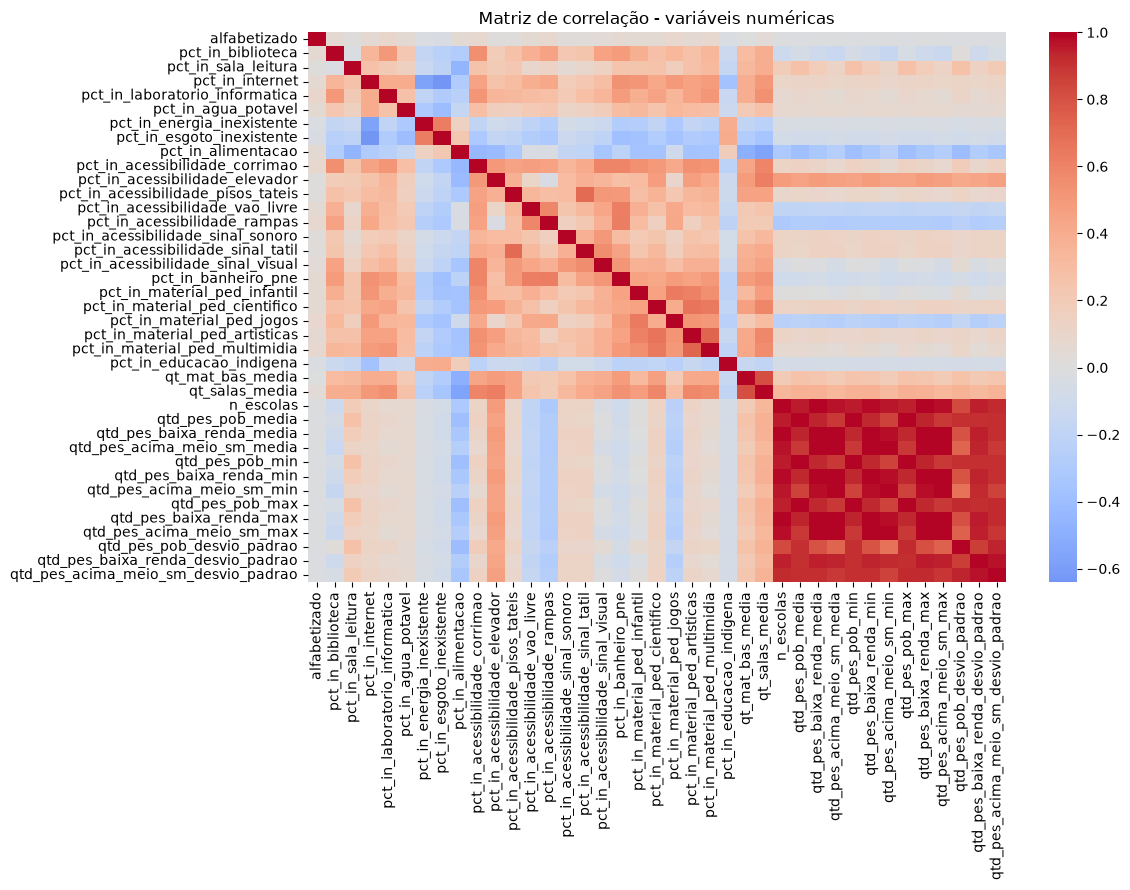

In [79]:
plt.figure(figsize=(12, 9))
sns.heatmap(df_master[numericas].corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlação - variáveis numéricas")
plt.tight_layout()
plt.show()

Observando os boxplots das variaveis do biblioteca, internet, acessibilidade, materiais pedagógicos, mostram distribuições quase identicas, pode ser devido estas feats serem indicadores de municipio e não a nivel escola, ja que id_escola esta mascarado. Vamos verificar a importancia para a target no desenvolvimento do modelo.

Já para os indicadores do cadastro unico, demonstram multicolinearidade forte, vamos escolher apenas uma para compor as feats para o modelo.